# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [2]:
data=pd.read_csv('/content/student_lifestyle_performance_dataset.csv')
top_15_students = data.nlargest(15, 'CGPA')
columns_to_keep = [
    'Age',
    'Study_Hours_per_Day',
    'Sleep_Hours',
    'Screen_Time_Hours',
    'Gym_Hours_per_Week'
]
df = top_15_students[columns_to_keep]
print(df)
#srednia = data['CGPA'].mean()
#data['powyzej_sr'] = data[data['CGPA'] > srednia]

     Age  Study_Hours_per_Day  Sleep_Hours  Screen_Time_Hours  \
109   23                 5.83         9.26               7.19   
405   17                 6.87         7.92               2.21   
464   25                 5.18         9.13               7.92   
657   22                 6.85         8.45               3.84   
843   24                 4.64         8.34               3.28   
171   20                 8.05         7.34               6.46   
475   19                 5.71         8.07               2.98   
639   19                 7.30         8.57               3.96   
659   20                 3.85         9.22               7.14   
682   25                 4.87         8.25               4.95   
156   24                 5.41         7.66               5.62   
902   25                 7.70         6.21               4.73   
904   19                 5.50         6.13               2.12   
940   24                 5.54         9.41               4.70   
768   24                 

## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [ ]:
top_15_students['Czas_wolny'] = (22.5-top_15_students['Study_Hours_per_Day']-top_15_students['Screen_Time_Hours']-top_15_students['Sleep_Hours']-(top_15_students['Gym_Hours_per_Week'] / 7))
top_15_students['Czas_wolny'] = top_15_students['Czas_wolny'].round(2)
columns_to_show_v2 = [
    'Czas_wolny',
    'Study_Hours_per_Day',
    'Sleep_Hours',
    'Screen_Time_Hours',
    'Gym_Hours_per_Week'
]
df_2 = top_15_students[columns_to_show_v2]
print(df_2)

     Czas_wolny  Study_Hours_per_Day  Sleep_Hours  Screen_Time_Hours  \
109       -0.64                 5.83         9.26               7.19   
405        2.91                 6.87         7.92               2.21   
464       -0.85                 5.18         9.13               7.92   
657        1.55                 6.85         8.45               3.84   
843        5.73                 4.64         8.34               3.28   
171        0.65                 8.05         7.34               6.46   
475        3.89                 5.71         8.07               2.98   
639        1.49                 7.30         8.57               3.96   
659        1.55                 3.85         9.22               7.14   
682        4.43                 4.87         8.25               4.95   
156        3.78                 5.41         7.66               5.62   
902        3.86                 7.70         6.21               4.73   
904        7.43                 5.50         6.13               

## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [3]:
data=pd.read_csv('/content/student_lifestyle_performance_dataset.csv')
only_18_plus = data[data['Age']>=18]
#print(only_18_plus)
summary_df = only_18_plus.groupby('Branch').agg(Sredni_poziom_stresu=('Stress_Level_1_to_10', 'mean'), Mediana_czasu_snu=('Sleep_Hours', 'median')).reset_index()
summary_df = summary_df.sort_values(by='Sredni_poziom_stresu', ascending=False).round(2)
print(summary_df)

       Branch  Sredni_poziom_stresu  Mediana_czasu_snu
1       Civil                  4.63               6.71
2         ECE                  4.63               6.40
5  Mechanical                  4.61               6.64
3  Electrical                  4.54               6.31
0         CSE                  4.53               6.54
4          IT                  4.45               6.76


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

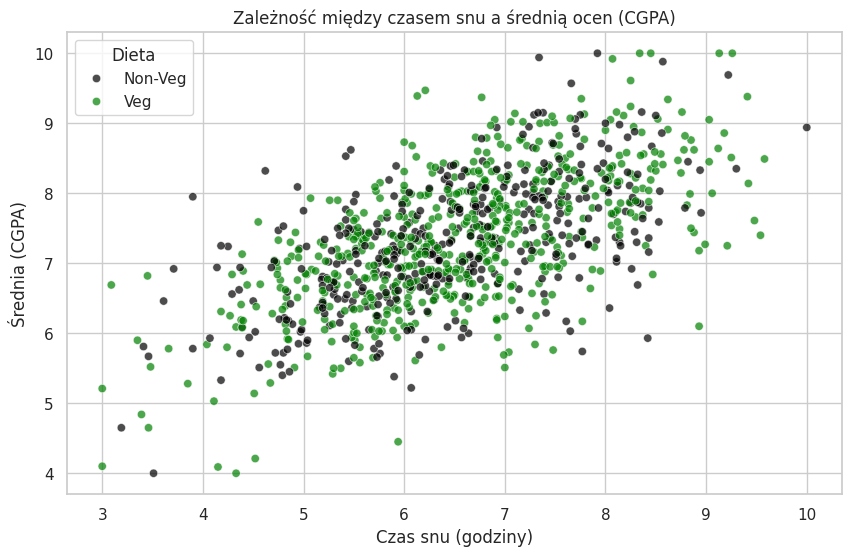

In [4]:
data['Branch'] = data['Branch'].replace({'IT': 'IT/CSE', 'CSE': 'IT/CSE'})
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Sleep_Hours',
    y='CGPA',
    hue='Diet_Type',
    palette={'Veg': 'green', 'Non-Veg': 'black'},
    alpha=0.7
)
plt.title('Zależność między czasem snu a średnią ocen (CGPA)')
plt.xlabel('Czas snu (godziny)')
plt.ylabel('Średnia (CGPA)')
plt.legend(title='Dieta')

/tmp/ipykernel_824/774876221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


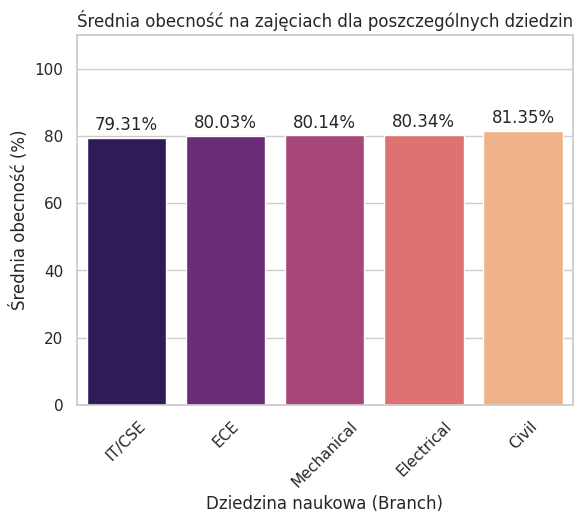

In [12]:
mean_attendance = data.groupby('Branch')['Attendance_Percentage'].mean().sort_values()
ax = sns.barplot(
    data=data,
    x='Branch',
    y='Attendance_Percentage',
    order=mean_attendance.index,
    errorbar=None,
    palette="magma"
)
plt.title('Średnia obecność na zajęciach dla poszczególnych dziedzin')
plt.xlabel('Dziedzina naukowa (Branch)')
plt.ylabel('Średnia obecność (%)')
plt.ylim(0, 110)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

/tmp/ipykernel_824/2193906465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.barplot(data=topic_popularity, x='topic', y='views', palette='magma')


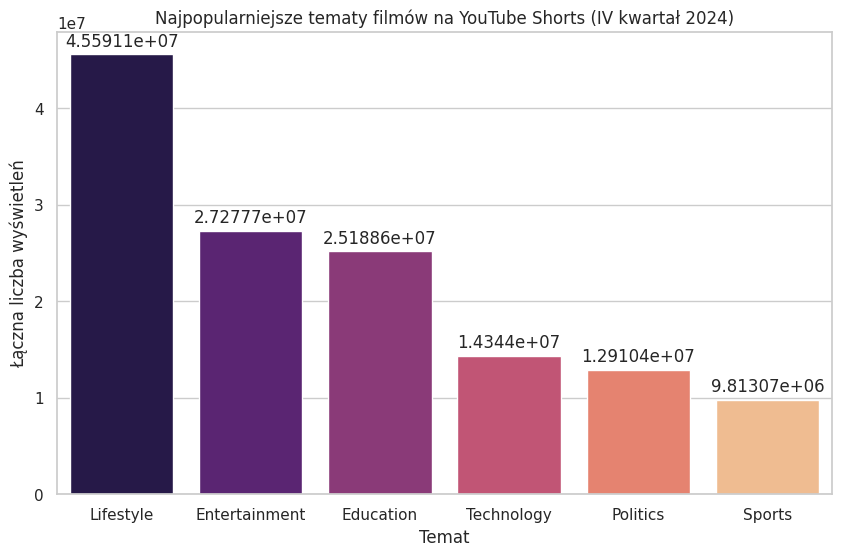

In [14]:
data = pd.read_csv('/content/social_media_viral_content_dataset.csv')
#print(data)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

data['post_datetime'] = pd.to_datetime(data['post_datetime'])
q4_2024 = data[(data['post_datetime'].dt.year == 2024) & (data['post_datetime'].dt.quarter == 4)]
yt_shorts = q4_2024[(q4_2024['platform'] == 'YouTube Shorts') & (q4_2024['content_type']=='video')]
topic_popularity = yt_shorts.groupby('topic')['views'].sum().reset_index()
topic_popularity = topic_popularity.sort_values(by='views', ascending=False)
bx = sns.barplot(data=topic_popularity, x='topic', y='views', palette='magma')
plt.title('Najpopularniejsze tematy filmów na YouTube Shorts (IV kwartał 2024)')
plt.xlabel('Temat')
plt.ylabel('Łączna liczba wyświetleń')
for container in bx.containers:
    bx.bar_label(container, padding=3)

/tmp/ipykernel_824/3382282324.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_engagement_rate = sns.barplot(


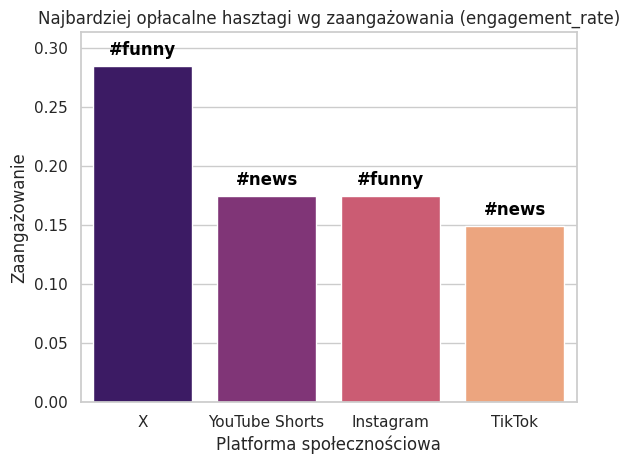

In [15]:
data['hashtag_list'] = data['hashtags'].str.split(' ')
data_exploded = data.explode('hashtag_list')
hashtag_engagement_rate = data_exploded.groupby(['platform', 'hashtag_list'])['engagement_rate'].mean().reset_index()
idx_engagement_rate = hashtag_engagement_rate.groupby('platform')['engagement_rate'].idxmax()
best_hashtags_engagement_rate = hashtag_engagement_rate.loc[idx_engagement_rate].sort_values(by='engagement_rate', ascending=False)
plt.ticklabel_format(style='plain', axis='y')
ax_engagement_rate = sns.barplot(
    data=best_hashtags_engagement_rate,
    x='platform',
    y='engagement_rate',
    palette='magma'
)

plt.title('Najbardziej opłacalne hasztagi wg zaangażowania (engagement_rate)')
plt.xlabel('Platforma społecznościowa')
plt.ylabel('Zaangażowanie')
plt.ylim(0, best_hashtags_engagement_rate['engagement_rate'].max() * 1.1)
for j, bar in enumerate(ax_engagement_rate.patches):
      hashtag_name = best_hashtags_engagement_rate.iloc[j]['hashtag_list']
      ax_engagement_rate.annotate(
          hashtag_name,
          xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
          xytext=(0, 5),
          textcoords="offset points",
          ha='center',
          va='bottom',
          fontsize=12,
          fontweight='bold',
          color='black'
      )